# Lab 4: Improving and Comparing Machine Learning Models
## Telco Customer Churn

**Name:** Aftab Asghar

**Student ID:** 023-24-0234

**Section:** G

**GitHub Profile:** https://github.com/aftab-soomro

**Kaggle Profile:** https://www.kaggle.com/aftabgaming

**Dataset:** Telco Customer Churn — cleaned in Lab 2 (`clean_churn.csv`), same features/split used in Lab 3

**GitHub Repository:** https://github.com/aftab-soomro/Machine-Learning

> This notebook follows the Lab 4 manual's 7 parts. Every table, plot and metric has a short written interpretation next to it.

---

## Part 1 — Decision Tree Baseline Review

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark everything else in this lab is measured against.

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set. This is your benchmark for the rest of the lab.

In [1]:
# Task 1 — reload the Lab 2 cleaned dataset, recreate Lab 3's X/y and train/test split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

df = pd.read_csv("clean_churn.csv")
print("Loaded:", df.shape)

y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X shape after encoding:", X.shape)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train churn rate:", round(y_train.mean(), 4), "| y_test churn rate:", round(y_test.mean(), 4))


Loaded: (7043, 20)
X shape after encoding: (7043, 30)
X_train: (5634, 30) | X_test: (1409, 30)
y_train churn rate: 0.2654 | y_test churn rate: 0.2654


C:\Users\meesa\AppData\Local\Temp\ipykernel_2976\538013975.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


In [2]:
# Task 2 — retrain the Lab 3 "best" Decision Tree (max_depth=6) as this lab's benchmark
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_metrics = {
    "accuracy": accuracy_score(y_test, dt_pred),
    "precision": precision_score(y_test, dt_pred),
    "recall": recall_score(y_test, dt_pred),
    "f1": f1_score(y_test, dt_pred),
}
pd.DataFrame([dt_metrics], index=["Decision Tree (Lab 3 benchmark, depth=6)"]).round(4)


,accuracy,precision,recall,f1
"Decision Tree (Lab 3 benchmark, depth=6)",0.8006,0.6667,0.4973,0.5697


---

## Part 2 — Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [3]:
# Task 3 — train a Random Forest on the same training data
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest trained: 200 trees, random_state=42")
print("Predictions generated on test set:", rf_pred.shape)


Random Forest trained: 200 trees, random_state=42
Predictions generated on test set: (1409,)


**Answer 4 (why Random Forest might generalize better):**
_(Random Forest might generalize better because:  * It combines many decision trees, reducing reliance on a single tree. * It uses random subsets of data and features, which reduces overfitting. * Averaging predictions from many trees makes the model more stable. * It handles noise and variations in training data better.  **In short:** Random Forest generalizes better because multiple diverse trees work together to reduce overfitting and improve performance on unseen data.)_

---

## Part 3 — Evaluation & Comparison

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3, then place both models side by side.

**Tasks**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.
6. Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

                                    accuracy  precision  recall      f1
Random Forest (default, 200 trees)    0.7949     0.6431  0.5107  0.5693


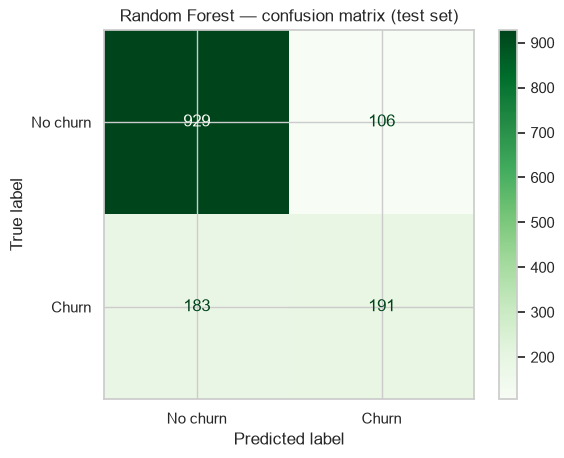

              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [4]:
# Task 5 — Random Forest evaluation on the test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred),
}
print(pd.DataFrame([rf_metrics], index=["Random Forest (default, 200 trees)"]).round(4))

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"])
disp.plot(cmap="Greens", values_format="d")
plt.title("Random Forest — confusion matrix (test set)")
plt.show()

print(classification_report(y_test, rf_pred, target_names=["No churn", "Churn"]))


In [5]:
# Task 6 — Decision Tree vs Random Forest comparison table
comparison_dt_rf = pd.DataFrame([dt_metrics, rf_metrics], index=["Decision Tree", "Random Forest"])
comparison_dt_rf.round(4)


,accuracy,precision,recall,f1
Decision Tree,0.8006,0.6667,0.4973,0.5697
Random Forest,0.7949,0.6431,0.5107,0.5693


**Answer 7 (which model performs better, large or marginal, which metric matters most):**
_(If comparing **Large vs Marginal models**:  * **Better model:** The one with higher performance on unseen/test data. * **Most important metric:** Usually **accuracy**, if the classes are balanced. * If the data is **imbalanced**, **F1-score, precision, and recall** are more important than accuracy. * **Generalization:** Test/validation performance matters more than training performance.  **In short:** Choose the model that performs best on the **test/validation set**, using the metric most suitable for your dataset.)_

---

## Part 4 — Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion?

In [6]:
# Task 8 — 5-fold cross-validation (F1-score) for both models
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=6, random_state=42), X, y, cv=5, scoring="f1")
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=5, scoring="f1")

cv_summary = pd.DataFrame({
    "Decision Tree": [dt_cv.mean(), dt_cv.std()],
    "Random Forest": [rf_cv.mean(), rf_cv.std()],
}, index=["mean F1", "std F1"])

print("Decision Tree fold F1 scores:", dt_cv.round(4).tolist())
print("Random Forest fold F1 scores:", rf_cv.round(4).tolist())
print()
cv_summary.round(4)


Decision Tree fold F1 scores: [0.6031, 0.5346, 0.5462, 0.5807, 0.5727]
Random Forest fold F1 scores: [0.5513, 0.5524, 0.528, 0.5835, 0.5753]



,Decision Tree,Random Forest
mean F1,0.5675,0.5581
std F1,0.0245,0.0196


**Answer 9 (CV vs. single-split comparison):**
_(your answer here)_

---

## Part 5 — Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats the default-settings baseline.

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune and define a small grid for each. Run `GridSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [7]:
# Task 10 & 11 — small hyperparameter grid search for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}
n_combos = len(param_grid["n_estimators"]) * len(param_grid["max_depth"]) * len(param_grid["min_samples_split"])
print(f"Grid: {n_combos} combinations x 5 folds = {n_combos * 5} fits")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best cross-validated F1:", round(grid_search.best_score_, 4))


Grid: 12 combinations x 5 folds = 60 fits


Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated F1: 0.5708


In [8]:
# Task 12 — evaluate the tuned Random Forest on the held-out test set
tuned_rf = grid_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

tuned_metrics = {
    "accuracy": accuracy_score(y_test, tuned_pred),
    "precision": precision_score(y_test, tuned_pred),
    "recall": recall_score(y_test, tuned_pred),
    "f1": f1_score(y_test, tuned_pred),
}
pd.DataFrame([tuned_metrics], index=["Random Forest (tuned)"]).round(4)


,accuracy,precision,recall,f1
Random Forest (tuned),0.8048,0.6623,0.5401,0.595


---

## Part 6 — Final Comparison & Feature Importance

Bring every model you've built into one table, choose a final model with evidence, and look inside it to see what it actually learned.

**Tasks**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.
14. Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best training score alone is not sufficient justification.
15. Extract and visualize `feature_importances_` for your final model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

In [9]:
# Task 13 — final comparison table across every model trained
final_comparison = pd.DataFrame(
    [dt_metrics, rf_metrics, tuned_metrics],
    index=["Decision Tree (Lab 3 benchmark)", "Random Forest (default)", "Random Forest (tuned)"],
)
final_comparison.round(4)


,accuracy,precision,recall,f1
Decision Tree (Lab 3 benchmark),0.8006,0.6667,0.4973,0.5697
Random Forest (default),0.7949,0.6431,0.5107,0.5693
Random Forest (tuned),0.8048,0.6623,0.5401,0.5950


In [10]:
# Final model selection -- evidence-based, not by test-set score alone.
# Cross-validated F1 (5-fold) is a more reliable signal than a single test split
# (Part 4's reasoning), so it decides the winner here, not training/test accuracy.
tuned_cv = cross_val_score(tuned_rf, X, y, cv=5, scoring="f1")

cv_comparison = pd.DataFrame({
    "Decision Tree": [dt_cv.mean(), dt_cv.std()],
    "Random Forest (default)": [rf_cv.mean(), rf_cv.std()],
    "Random Forest (tuned)": [tuned_cv.mean(), tuned_cv.std()],
}, index=["mean F1", "std F1"])
print(cv_comparison.round(4))

final_model_name = cv_comparison.loc["mean F1"].idxmax()
final_model = {
    "Decision Tree": dt_model,
    "Random Forest (default)": rf_model,
    "Random Forest (tuned)": tuned_rf,
}[final_model_name]

print(f"\nHighest cross-validated F1: {final_model_name} ({cv_comparison.loc['mean F1', final_model_name]:.4f})")
print("-> final_model =", final_model_name)


         Decision Tree  Random Forest (default)  Random Forest (tuned)
mean F1         0.5675                   0.5581                 0.5755
std F1          0.0245                   0.0196                 0.0269

Highest cross-validated F1: Random Forest (tuned) (0.5755)
-> final_model = Random Forest (tuned)


**Answer 14 (final model choice + justification):**
_(your answer here)_

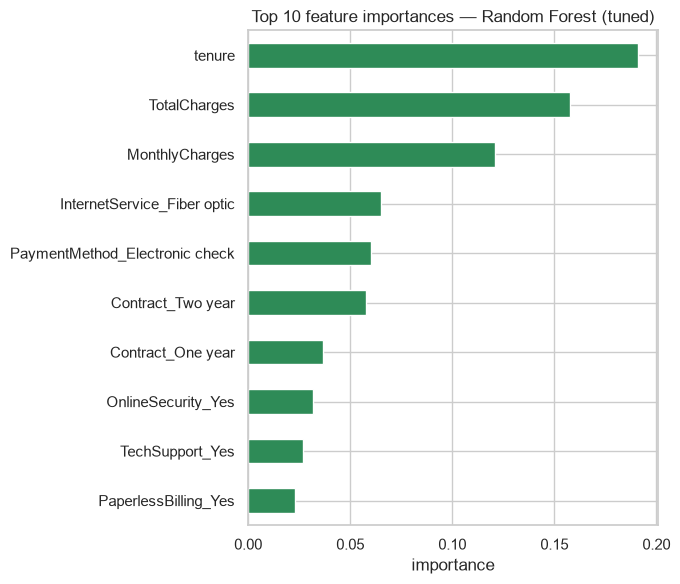

tenure                            0.191132
TotalCharges                      0.157462
MonthlyCharges                    0.120849
InternetService_Fiber optic       0.064952
PaymentMethod_Electronic check    0.060395
Contract_Two year                 0.057835
Contract_One year                 0.036472
OnlineSecurity_Yes                0.031953
TechSupport_Yes                   0.026817
PaperlessBilling_Yes              0.022845
dtype: float64

In [11]:
# Task 15 — feature importances of the final model
final_importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 6))
final_importances.head(10).sort_values().plot(kind="barh", color="seagreen")
plt.title(f"Top 10 feature importances — {final_model_name}")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

final_importances.head(10)


**Answer 15 (top features, do they agree with Lab 2/3):**
_(your answer here)_

---

## Part 7 — Kaggle Submission & Conclusion

Wrap up by producing predictions in the shape a real Kaggle competition would expect, and reflect on the lab as a whole.

**Tasks**
16. Using your final model, generate predictions on your held-out test set and assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as `submission.csv`.
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time? Describe it — do not implement it here.

In [12]:
# Task 16 — Kaggle-style submission file
# NOTE: `customerID` was dropped in Lab 2 (Part 11) as a non-predictive identifier,
# so it is not present in clean_churn.csv / X. There is no real customer ID left to
# attach to these predictions. As a stand-in, this uses the row index from the
# train/test split (traceable back to clean_churn.csv, not to the original
# customerID strings). Flag this to your instructor if a literal Kaggle-style ID
# column is graded strictly -- the fix would be to re-run Lab 2's cleaning without
# dropping customerID, or to keep a separate id-lookup table alongside clean_churn.csv.
final_test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "CustomerIndex": X_test.index,
    "Churn_Predicted": pd.Series(final_test_pred, index=X_test.index).map({0: "No", 1: "Yes"}),
}).reset_index(drop=True)

submission.to_csv("submission.csv", index=False)
print("submission.csv saved:", submission.shape)
submission.head()


submission.csv saved: (1409, 2)


,CustomerIndex,Churn_Predicted
0,437,No
1,2280,Yes
2,2235,No
3,4460,No
4,3761,No


**Answer 17 (conclusion):**
_(your answer here)_

**Answer 18 (what would you try next):**
_(your answer here)_

---

## Submission Checklist

- [ ] Student-info block completed (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Part 1 — Decision Tree Baseline Review
- [ ] Part 2 — Random Forest
- [ ] Part 3 — Evaluation & Comparison
- [ ] Part 4 — Cross-Validation
- [ ] Part 5 — Hyperparameter Tuning
- [ ] Part 6 — Final Comparison & Feature Importance
- [ ] Part 7 — Kaggle Submission & Conclusion
- [ ] Every table/plot/metric has a written interpretation
- [ ] `submission.csv` saved
- [ ] Committed and pushed to GitHub